Sample:  2006-12-01 00:00:00  to  2026-01-01 00:00:00
N obs:   230

Mean Δe (monthly):           0.007281
Mean i - i* (monthly):       0.022936
Std  Δe:                     0.022146
Std  i - i*:                 0.017249
Corr(Δe, i-i*):             0.1860

FAMA (1984) UIP REGRESSION
  Δe_{t+1} = α + β (i_t - i*_t) + u_{t+1}

  α (const)  = 0.001804  (se = 0.004501)
  β          = 0.2388  (se = 0.1861)
  R²         = 0.0346
  N          = 230

  H0: β = 1  t-stat = -4.091
  H0: β = 0  t-stat = 1.283


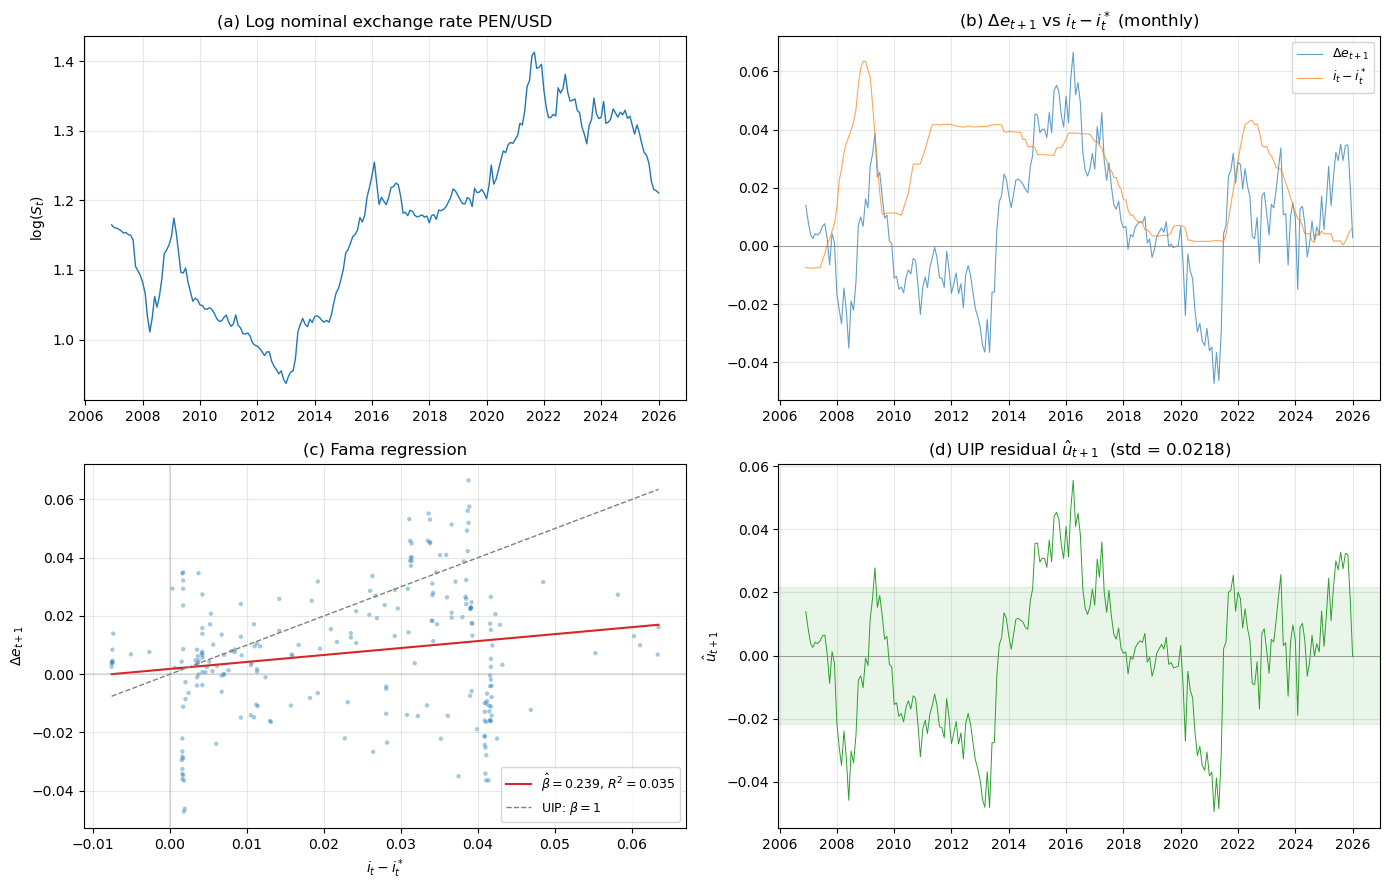


SUMMARY
  β̂ = 0.2388
  → UIP rejected: β < 1 (partial puzzle)
  Std(UIP residual) = 0.0218 (monthly)
  Std(UIP residual) = 0.0377 (quarterly, approx)
  This is the empirical counterpart of ψ_t in the I-M model

UIP RESIDUAL vs FXI (quarterly, % of GDP)
N obs (quarterly): 77
Corr(û, FXI/GDP):  -0.1216

  û_t = a + b · (FXI/GDP)_t + v_t
  a (const)  = -0.015828  (se = 0.005444)
  b (FXI)    = -0.000406  (se = 0.000583)
  t-stat     = -0.697
  R²         = 0.0148

  û_t = a + b · (FXI/GDP)_{t-1} + v_t
  b (FXI_{t-1}) = -0.001149  (t = -2.225)
  R²            = 0.1213


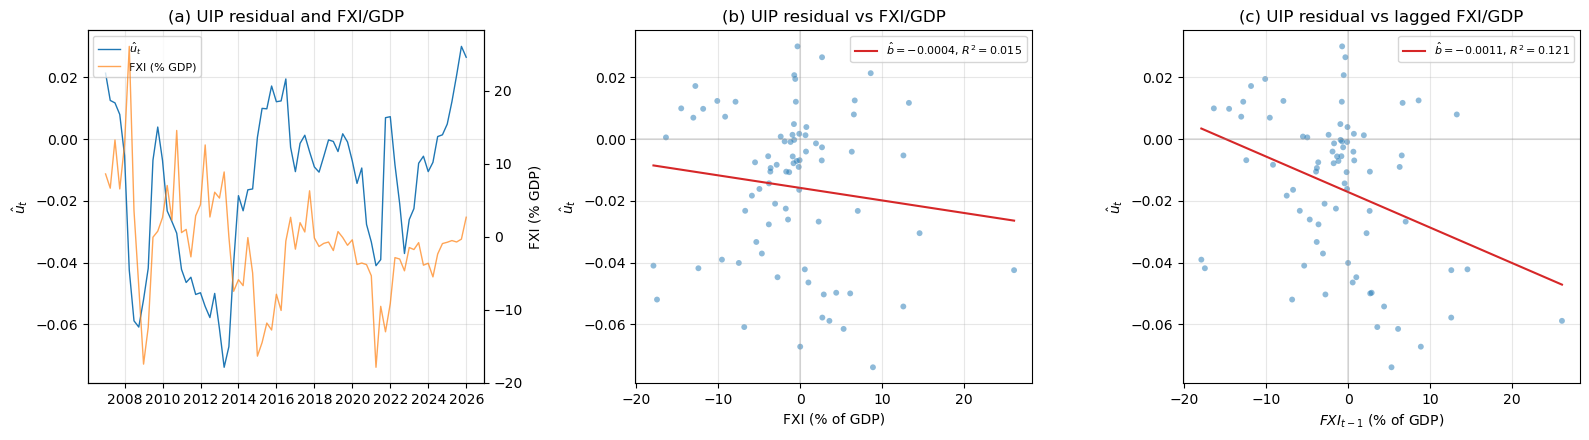


  û_t = a + b1 · (FXI/GDP)_t + b2 · (FXI/GDP)_{t-1} + v_t
  a (const)      = -0.016947  (se = 0.005081)
  b1 (FXI)       = 0.000487  (se = 0.000480, t = 1.014)
  b2 (FXI_lag)   = -0.001470  (se = 0.000398, t = -3.689)
  R²             = 0.1332
  N              = 76


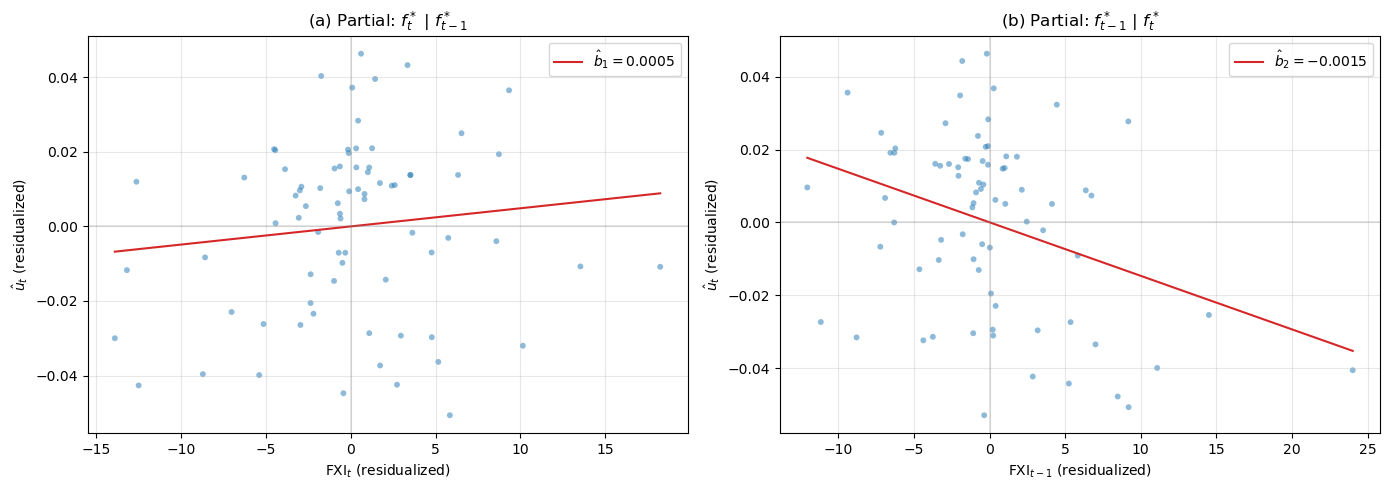

In [7]:
"""
UIP Test for Peru
=================
Standard Fama (1984) regression:
    Δe_{t+1} = α + β (i_t - i*_t) + u_{t+1}

UIP holds if α=0, β=1. The classic "forward premium puzzle" is β < 0.

Columns in Monthly sheet:
  fedfunds  — US policy rate (annualised %)
  irate     — Peru policy rate (annualised %)
  exrate    — PEN/USD nominal exchange rate (level)
  e(+1)     — (if present) forward-looking exrate, otherwise we lead exrate
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats

# ══════════════════════════════════════════════════════════════════════════════
# 1. Load data
# ══════════════════════════════════════════════════════════════════════════════
data_monthly = pd.read_excel(
    "../data/DataParametrization.xlsx",
    sheet_name="Monthly",
    index_col="date"
)

# Coerce numeric
for col in ['fedfunds', 'irate', 'exrate']:
    data_monthly[col] = pd.to_numeric(data_monthly[col], errors='coerce')

df = data_monthly[['exrate', 'irate', 'fedfunds', 'e(+1)']].dropna()

# ══════════════════════════════════════════════════════════════════════════════
# 2. Construct variables
# ══════════════════════════════════════════════════════════════════════════════
# Log exchange rate
df['ln_e'] = np.log(df['exrate'])
df['ln_exp_e'] = np.log(df['e(+1)'])

# Monthly exchange rate depreciation: Δe_{t+1} = ln(S_{t+1}) - ln(S_t)
df['de'] = df['ln_exp_e'] - df['ln_e']   # forward-looking

# Interest rate differential (monthly): convert annualised % to monthly decimal
# i_t - i*_t  (Peru minus US)
df['i_diff'] = (df['irate'] - df['fedfunds']) / 100

# Drop last row (NaN from forward shift) and any remaining NaNs
df = df.dropna(subset=['de', 'i_diff'])

print(f'Sample:  {df.index[0]}  to  {df.index[-1]}')
print(f'N obs:   {len(df)}')
print(f'\nMean Δe (monthly):           {df["de"].mean():.6f}')
print(f'Mean i - i* (monthly):       {df["i_diff"].mean():.6f}')
print(f'Std  Δe:                     {df["de"].std():.6f}')
print(f'Std  i - i*:                 {df["i_diff"].std():.6f}')
print(f'Corr(Δe, i-i*):             {df["de"].corr(df["i_diff"]):.4f}')

# ══════════════════════════════════════════════════════════════════════════════
# 3. Fama regression:  Δe_{t+1} = α + β (i_t - i*_t) + u_{t+1}
# ══════════════════════════════════════════════════════════════════════════════
X = sm.add_constant(df['i_diff'])
fama = sm.OLS(df['de'], X).fit(cov_type='HAC', cov_kwds={'maxlags': 6})

print('\n' + '='*60)
print('FAMA (1984) UIP REGRESSION')
print('='*60)
print(f'  Δe_{{t+1}} = α + β (i_t - i*_t) + u_{{t+1}}')
print(f'\n  α (const)  = {fama.params.iloc[0]:.6f}  (se = {fama.bse.iloc[0]:.6f})')
print(f'  β          = {fama.params.iloc[1]:.4f}  (se = {fama.bse.iloc[1]:.4f})')
print(f'  R²         = {fama.rsquared:.4f}')
print(f'  N          = {fama.nobs:.0f}')
print(f'\n  H0: β = 1  t-stat = {(fama.params.iloc[1] - 1) / fama.bse.iloc[1]:.3f}')
print(f'  H0: β = 0  t-stat = {fama.params.iloc[1] / fama.bse.iloc[1]:.3f}')

# UIP residual
df['uip_resid'] = fama.resid

# ══════════════════════════════════════════════════════════════════════════════
# 4. Plots
# ══════════════════════════════════════════════════════════════════════════════
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# ── (a) Exchange rate and interest rate differential ──────────────────────
ax = axes[0, 0]
ax.plot(df.index, df['ln_e'], linewidth=1.0)
ax.set_ylabel(r'$\log(S_t)$')
ax.set_title('(a) Log nominal exchange rate PEN/USD')
ax.grid(alpha=0.3)

# ── (b) Δe and i - i* ────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(df.index, df['de'], label=r'$\Delta e_{t+1}$',
        linewidth=0.8, alpha=0.7)
ax.plot(df.index, df['i_diff'], label=r'$i_t - i^*_t$',
        linewidth=0.8, alpha=0.7)
ax.axhline(0, color='grey', linewidth=0.5)
ax.set_title(r'(b) $\Delta e_{t+1}$ vs $i_t - i^*_t$ (monthly)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── (c) Fama scatter + regression line ───────────────────────────────────
ax = axes[1, 0]
ax.scatter(df['i_diff'], df['de'], s=10, alpha=0.4, edgecolors='none')
xgrid = np.linspace(df['i_diff'].min(), df['i_diff'].max(), 100)
ax.plot(xgrid, fama.params.iloc[0] + fama.params.iloc[1] * xgrid,
        color='C3', linewidth=1.5,
        label=rf'$\hat\beta = {fama.params.iloc[1]:.3f}$, $R^2 = {fama.rsquared:.3f}$')
# 45-degree line (UIP benchmark)
ax.plot(xgrid, xgrid, color='grey', linewidth=1, linestyle='--',
        label=r'UIP: $\beta = 1$')
ax.axhline(0, color='grey', linewidth=0.3)
ax.axvline(0, color='grey', linewidth=0.3)
ax.set_xlabel(r'$i_t - i^*_t$')
ax.set_ylabel(r'$\Delta e_{t+1}$')
ax.set_title('(c) Fama regression')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── (d) UIP residual over time ───────────────────────────────────────────
ax = axes[1, 1]
ax.plot(df.index, df['uip_resid'], linewidth=0.7, color='C2')
ax.axhline(0, color='grey', linewidth=0.5)
# Shade ±1 std
std_u = df['uip_resid'].std()
ax.axhspan(-std_u, std_u, alpha=0.1, color='C2')
ax.set_title(rf'(d) UIP residual $\hat u_{{t+1}}$  (std = {std_u:.4f})')
ax.set_ylabel(r'$\hat{u}_{t+1}$')
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('../figures/uip_test.pdf', bbox_inches='tight')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 5. Summary table
# ══════════════════════════════════════════════════════════════════════════════
print('\n' + '='*60)
print('SUMMARY')
print('='*60)
print(f'  β̂ = {fama.params.iloc[1]:.4f}')
if fama.params.iloc[1] < 0:
    print('  → Forward premium puzzle: β < 0')
elif fama.params.iloc[1] < 1:
    print('  → UIP rejected: β < 1 (partial puzzle)')
else:
    print('  → Cannot reject UIP direction: β ≥ 1')
print(f'  Std(UIP residual) = {std_u:.4f} (monthly)')
print(f'  Std(UIP residual) = {std_u * np.sqrt(3):.4f} (quarterly, approx)')
print(f'  This is the empirical counterpart of ψ_t in the I-M model')

# ══════════════════════════════════════════════════════════════════════════════
# 6. UIP residual vs FXI (quarterly, normalized by GDP)
# ══════════════════════════════════════════════════════════════════════════════

# ── Load daily FXI data ──────────────────────────────────────────────────────
df_daily = pd.read_excel("../data/DataParametrization.xlsx", sheet_name="Daily")
df_daily.index = pd.to_datetime(df_daily['date'])
df_daily['fxi'] = df_daily.fx_spot - df_daily.fx_cdr - df_daily.fx_swap

# ── Load quarterly GDP ───────────────────────────────────────────────────────
data_quarterly = pd.read_excel("../data/DataParametrization.xlsx",
                               sheet_name="Quarterly", index_col="date")
data_quarterly['Y_e'] = pd.to_numeric(data_quarterly['Y_e'], errors='coerce')

# ── Aggregate FXI to quarterly, normalize by GDP ─────────────────────────────
fxi_quarterly = df_daily.fxi.resample('QE').sum()
# Align lengths
min_len = min(len(fxi_quarterly), len(data_quarterly['Y_e'].dropna()))
fxi_norm = (fxi_quarterly.values[:min_len] / data_quarterly['Y_e'].dropna().values[:min_len]) * 100
fxi_q = pd.Series(fxi_norm, index=fxi_quarterly.index[:min_len], name='fxi_gdp')

# ── Aggregate UIP residual to quarterly ──────────────────────────────────────
df['psi'] = df['de'] - df['i_diff']
uip_q = df['psi'].resample('QE').mean()

# ── Merge ────────────────────────────────────────────────────────────────────
merged = pd.DataFrame({
    'uip_resid': uip_q,
    'fxi': fxi_q
}).dropna()

print(f'\n{"="*60}')
print('UIP RESIDUAL vs FXI (quarterly, % of GDP)')
print(f'{"="*60}')
print(f'N obs (quarterly): {len(merged)}')
print(f'Corr(û, FXI/GDP):  {merged["uip_resid"].corr(merged["fxi"]):.4f}')

# ── Regression: û_t = a + b * (FXI/GDP)_t + v_t ─────────────────────────────
X_fxi = sm.add_constant(merged['fxi'])
reg_fxi = sm.OLS(merged['uip_resid'], X_fxi).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\n  û_t = a + b · (FXI/GDP)_t + v_t')
print(f'  a (const)  = {reg_fxi.params.iloc[0]:.6f}  (se = {reg_fxi.bse.iloc[0]:.6f})')
print(f'  b (FXI)    = {reg_fxi.params.iloc[1]:.6f}  (se = {reg_fxi.bse.iloc[1]:.6f})')
print(f'  t-stat     = {reg_fxi.params.iloc[1] / reg_fxi.bse.iloc[1]:.3f}')
print(f'  R²         = {reg_fxi.rsquared:.4f}')

# ── Lagged regression ────────────────────────────────────────────────────────
merged['fxi_lag'] = merged['fxi'].shift(1)
merged_lag = merged.dropna(subset=['fxi_lag'])
X_lag = sm.add_constant(merged_lag['fxi_lag'])
reg_lag = sm.OLS(merged_lag['uip_resid'], X_lag).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\n  û_t = a + b · (FXI/GDP)_{{t-1}} + v_t')
print(f'  b (FXI_{{t-1}}) = {reg_lag.params.iloc[1]:.6f}  (t = {reg_lag.params.iloc[1]/reg_lag.bse.iloc[1]:.3f})')
print(f'  R²            = {reg_lag.rsquared:.4f}')

# ── Plots ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# (a) Time series dual axis
ax = axes[0]
ax.plot(merged.index, merged['uip_resid'], linewidth=1.0, label=r'$\hat{u}_t$')
ax.set_ylabel(r'$\hat{u}_t$')
ax2 = ax.twinx()
ax2.plot(merged.index, merged['fxi'], linewidth=1.0, color='C1', alpha=0.7,
         label='FXI (% GDP)')
ax2.set_ylabel('FXI (% GDP)')
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=8, loc='upper left')
ax.set_title('(a) UIP residual and FXI/GDP')
ax.grid(alpha=0.3)

# (b) Contemporaneous scatter
ax = axes[1]
ax.scatter(merged['fxi'], merged['uip_resid'], s=18, alpha=0.5, edgecolors='none')
xg = np.linspace(merged['fxi'].min(), merged['fxi'].max(), 100)
ax.plot(xg, reg_fxi.params.iloc[0] + reg_fxi.params.iloc[1] * xg,
        color='C3', linewidth=1.5,
        label=rf'$\hat b = {reg_fxi.params.iloc[1]:.4f}$, $R^2 = {reg_fxi.rsquared:.3f}$')
ax.axhline(0, color='grey', linewidth=0.3)
ax.axvline(0, color='grey', linewidth=0.3)
ax.set_xlabel('FXI (% of GDP)')
ax.set_ylabel(r'$\hat{u}_t$')
ax.set_title(r'(b) UIP residual vs FXI/GDP')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# (c) Lagged scatter
ax = axes[2]
ax.scatter(merged_lag['fxi_lag'], merged_lag['uip_resid'], s=18, alpha=0.5, edgecolors='none')
xg2 = np.linspace(merged_lag['fxi_lag'].min(), merged_lag['fxi_lag'].max(), 100)
ax.plot(xg2, reg_lag.params.iloc[0] + reg_lag.params.iloc[1] * xg2,
        color='C3', linewidth=1.5,
        label=rf'$\hat b = {reg_lag.params.iloc[1]:.4f}$, $R^2 = {reg_lag.rsquared:.3f}$')
ax.axhline(0, color='grey', linewidth=0.3)
ax.axvline(0, color='grey', linewidth=0.3)
ax.set_xlabel(r'$FXI_{t-1}$ (% of GDP)')
ax.set_ylabel(r'$\hat{u}_t$')
ax.set_title(r'(c) UIP residual vs lagged FXI/GDP')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('../figures/uip_resid_vs_fxi_quarterly.pdf', bbox_inches='tight')
plt.show()

# ── Combined regression: contemporaneous + lagged ────────────────────────────
merged['fxi_lag'] = merged['fxi'].shift(1)
merged_both = merged.dropna(subset=['fxi_lag'])
X_both = sm.add_constant(merged_both[['fxi', 'fxi_lag']])
reg_both = sm.OLS(merged_both['uip_resid'], X_both).fit(cov_type='HAC', cov_kwds={'maxlags': 4})

print(f'\n  û_t = a + b1 · (FXI/GDP)_t + b2 · (FXI/GDP)_{{t-1}} + v_t')
print(f'  a (const)      = {reg_both.params.iloc[0]:.6f}  (se = {reg_both.bse.iloc[0]:.6f})')
print(f'  b1 (FXI)       = {reg_both.params.iloc[1]:.6f}  (se = {reg_both.bse.iloc[1]:.6f}, t = {reg_both.params.iloc[1]/reg_both.bse.iloc[1]:.3f})')
print(f'  b2 (FXI_lag)   = {reg_both.params.iloc[2]:.6f}  (se = {reg_both.bse.iloc[2]:.6f}, t = {reg_both.params.iloc[2]/reg_both.bse.iloc[2]:.3f})')
print(f'  R²             = {reg_both.rsquared:.4f}')
print(f'  N              = {reg_both.nobs:.0f}')

# ── Partial regression plots ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Partial out fxi_lag from both uip_resid and fxi
resid_y_1 = sm.OLS(merged_both['uip_resid'], sm.add_constant(merged_both['fxi_lag'])).fit().resid
resid_x_1 = sm.OLS(merged_both['fxi'], sm.add_constant(merged_both['fxi_lag'])).fit().resid

ax = axes[0]
ax.scatter(resid_x_1, resid_y_1, s=18, alpha=0.5, edgecolors='none')
xg = np.linspace(resid_x_1.min(), resid_x_1.max(), 100)
b1_line = np.polyfit(resid_x_1, resid_y_1, 1)
ax.plot(xg, b1_line[0] * xg + b1_line[1], color='C3', linewidth=1.5,
        label=rf'$\hat b_1 = {reg_both.params.iloc[1]:.4f}$')
ax.axhline(0, color='grey', linewidth=0.3)
ax.axvline(0, color='grey', linewidth=0.3)
ax.set_xlabel(r'FXI$_t$ (residualized)')
ax.set_ylabel(r'$\hat{u}_t$ (residualized)')
ax.set_title(r'(a) Partial: $f^*_t$ | $f^*_{t-1}$')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# Partial out fxi from both uip_resid and fxi_lag
resid_y_2 = sm.OLS(merged_both['uip_resid'], sm.add_constant(merged_both['fxi'])).fit().resid
resid_x_2 = sm.OLS(merged_both['fxi_lag'], sm.add_constant(merged_both['fxi'])).fit().resid

ax = axes[1]
ax.scatter(resid_x_2, resid_y_2, s=18, alpha=0.5, edgecolors='none')
xg2 = np.linspace(resid_x_2.min(), resid_x_2.max(), 100)
b2_line = np.polyfit(resid_x_2, resid_y_2, 1)
ax.plot(xg2, b2_line[0] * xg2 + b2_line[1], color='C3', linewidth=1.5,
        label=rf'$\hat b_2 = {reg_both.params.iloc[2]:.4f}$')
ax.axhline(0, color='grey', linewidth=0.3)
ax.axvline(0, color='grey', linewidth=0.3)
ax.set_xlabel(r'FXI$_{t-1}$ (residualized)')
ax.set_ylabel(r'$\hat{u}_t$ (residualized)')
ax.set_title(r'(b) Partial: $f^*_{t-1}$ | $f^*_t$')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
#plt.savefig('../paper/figures/uip_fxi_partial.pdf', bbox_inches='tight')
plt.show()